In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import ipywidgets as widgets
import scipy as sp

In [10]:
%matplotlib widget
plt.close("all")

In [11]:
spettri_dir = "data/spettri/"

available_spectra = [i for i in os.listdir(spettri_dir) if i.endswith(".xy") and "reference" not in i]

print("Available spectra:")
for i, spectrum in enumerate(available_spectra):
    print(f"{i}: {spectrum}")

Available spectra:
0: campione_perc_1.xy
1: campione_au_pt_1.xy
2: campione_20nm_1.xy
3: campione_9nm_1.xy
4: campione_6nm_1.xy


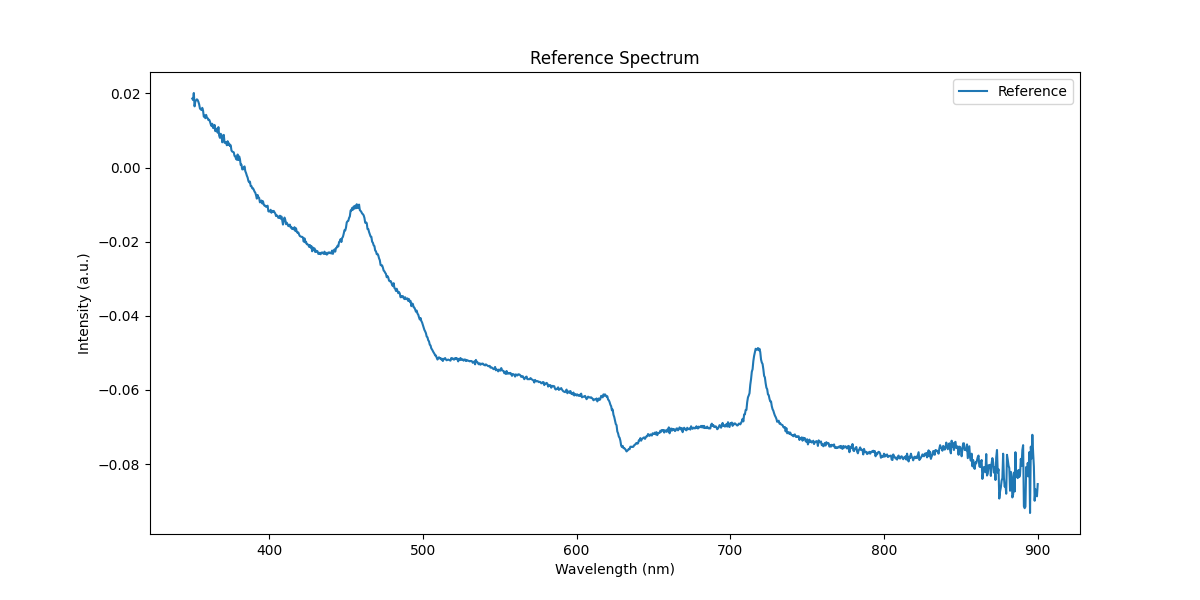

In [12]:
reference_spectrum = np.loadtxt(os.path.join(spettri_dir, "reference2.xy"))

plt.figure(figsize=(12, 6))

plt.plot(reference_spectrum[:, 0], -reference_spectrum[:, 1], label="Reference")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (a.u.)")
plt.title("Reference Spectrum")
plt.legend()
plt.show()

In [13]:

def lorentz(x, x0, gamma, A, offset):
    return A * gamma**2 / ((x - x0)**2 + gamma**2) + offset

def fit_lorentzian(x, y, initial_guess):
    popt, pcov = sp.optimize.curve_fit(lorentz, x, y, p0=initial_guess)
    return popt, pcov   # parametri ottimali e matrice di covarianza


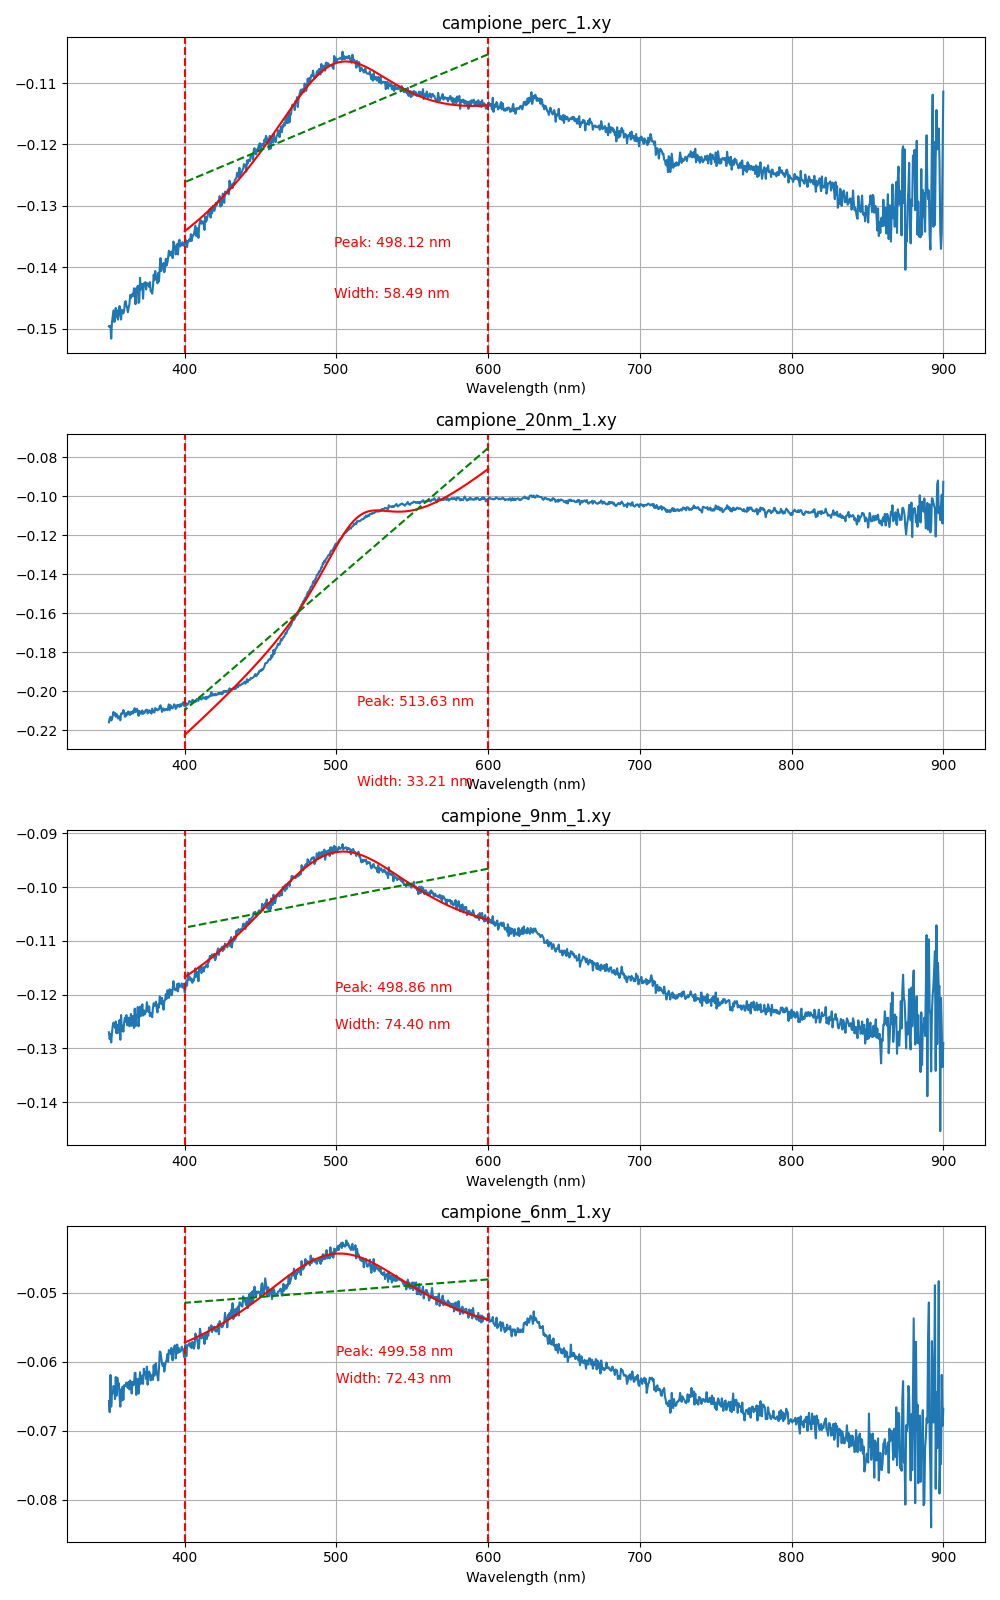

In [14]:
available_spectra = [i for i in available_spectra if "pt" not in i]
fig, axes = plt.subplots(len(available_spectra), 1, figsize=(10, 16))

peak_region = (400, 600)

params = {}

for ax, spectrum in zip(axes, available_spectra):

    data = np.loadtxt(os.path.join(spettri_dir, spectrum))
    data[:, 1] -= reference_spectrum[:, 1]

    ax.plot(data[:, 0], data[:, 1], label=spectrum)

    ax.axvline(peak_region[0], color="red", linestyle="--", label="Peak Region")
    ax.axvline(peak_region[1], color="red", linestyle="--")

    peak_region_mask = (data[:, 0] >= peak_region[0]) & (data[:, 0] <= peak_region[1])
    peak_region_data = data[peak_region_mask]
    baseline = np.polyfit(peak_region_data[:, 0], peak_region_data[:, 1], deg=1)
    baseline_values = np.polyval(baseline, peak_region_data[:, 0])

    peak_region_without_baseline = peak_region_data[:, 1] - baseline_values
    initial_guess = [peak_region_data[:, 0][np.argmax(peak_region_without_baseline)], 10, np.max(peak_region_without_baseline), 0]
    popt, pcov = fit_lorentzian(peak_region_data[:, 0], peak_region_without_baseline, initial_guess)

    params[spectrum] = {
        "peak_position": popt[0],
        "width": popt[1],
        "amplitude": popt[2],
        "baseline_offset": popt[3],
        "covariance": pcov
    }

    ax.plot(peak_region_data[:, 0], lorentz(peak_region_data[:, 0], *popt) + baseline_values, color="red", label="Lorentzian Fit")

    ax.text(popt[0], np.min(peak_region_data[:, 1]), f"Peak: {popt[0]:.2f} nm", color="red")
    ax.text(popt[0], np.min(peak_region_data[:, 1]) - np.std(peak_region_data[:, 1]), f"Width: {popt[1]:.2f} nm", color="red")

    ax.plot(peak_region_data[:, 0], baseline_values, color="green", linestyle="--", label="Baseline")

    ax.set_title(spectrum)
    ax.set_xlabel("Wavelength (nm)")
    ax.grid()
plt.tight_layout()
plt.show()

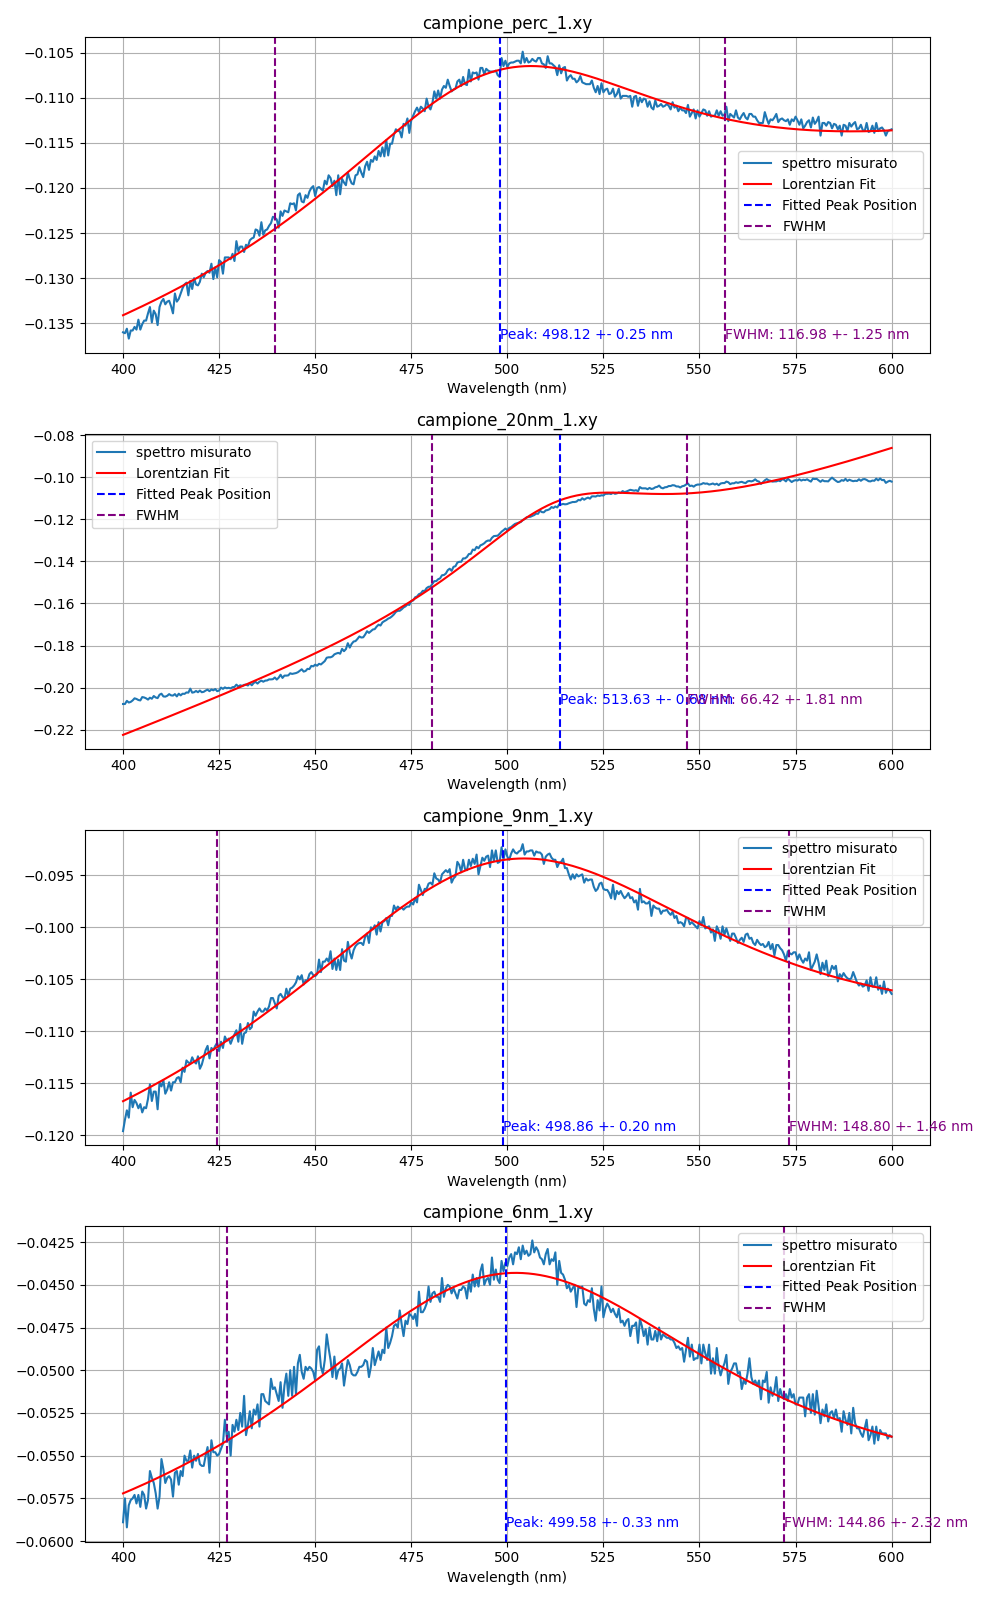

In [15]:
fig, axes = plt.subplots(len(available_spectra), 1, figsize=(10, 16))

for ax, spectrum, p in zip(axes, available_spectra, [params[s] for s in available_spectra]):

    data = np.loadtxt(os.path.join(spettri_dir, spectrum))
    data[:, 1] -= reference_spectrum[:, 1]

    peak_region_mask = (data[:, 0] >= peak_region[0]) & (data[:, 0] <= peak_region[1])
    peak_region_data = data[peak_region_mask]

    baseline = np.polyfit(peak_region_data[:, 0], peak_region_data[:, 1], deg=1)
    baseline_values = np.polyval(baseline, peak_region_data[:, 0])

    param_errors = np.sqrt(np.diag(p["covariance"]))

    ax.plot(peak_region_data[:, 0], peak_region_data[:, 1], label="spettro misurato")
    ax.plot(peak_region_data[:, 0], lorentz(peak_region_data[:, 0], p["peak_position"], p["width"], p["amplitude"], p["baseline_offset"]) + baseline_values, color="red", label="Lorentzian Fit")

    ax.axvline(p["peak_position"], color="blue", linestyle="--", label="Fitted Peak Position")
    ax.text(p["peak_position"], np.min(peak_region_data[:, 1]), f"Peak: {p['peak_position']:.2f} +- {param_errors[0]:.2f} nm", color="blue")

    # larghezza a mezza altezza (FWHM)
    fwhm = 2 * p["width"]
    ax.axvline(p["peak_position"] + fwhm/2, color="purple", linestyle="--", label="FWHM")
    ax.axvline(p["peak_position"] - fwhm/2, color="purple", linestyle="--")
    ax.text(p["peak_position"] + fwhm/2, np.min(peak_region_data[:, 1]), f"FWHM: {fwhm:.2f} +- {param_errors[1]:.2f} nm", color="purple")

    ax.set_title(spectrum)
    ax.set_xlabel("Wavelength (nm)")
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()
    

In [17]:
print("spettri: ", available_spectra)

spettri:  ['campione_perc_1.xy', 'campione_20nm_1.xy', 'campione_9nm_1.xy', 'campione_6nm_1.xy']


In [20]:
ordered_spectra = ["campione_6nm_1.xy", "campione_9nm_1.xy", "campione_perc_1.xy"]   #, "campione_20nm_1.xy"]

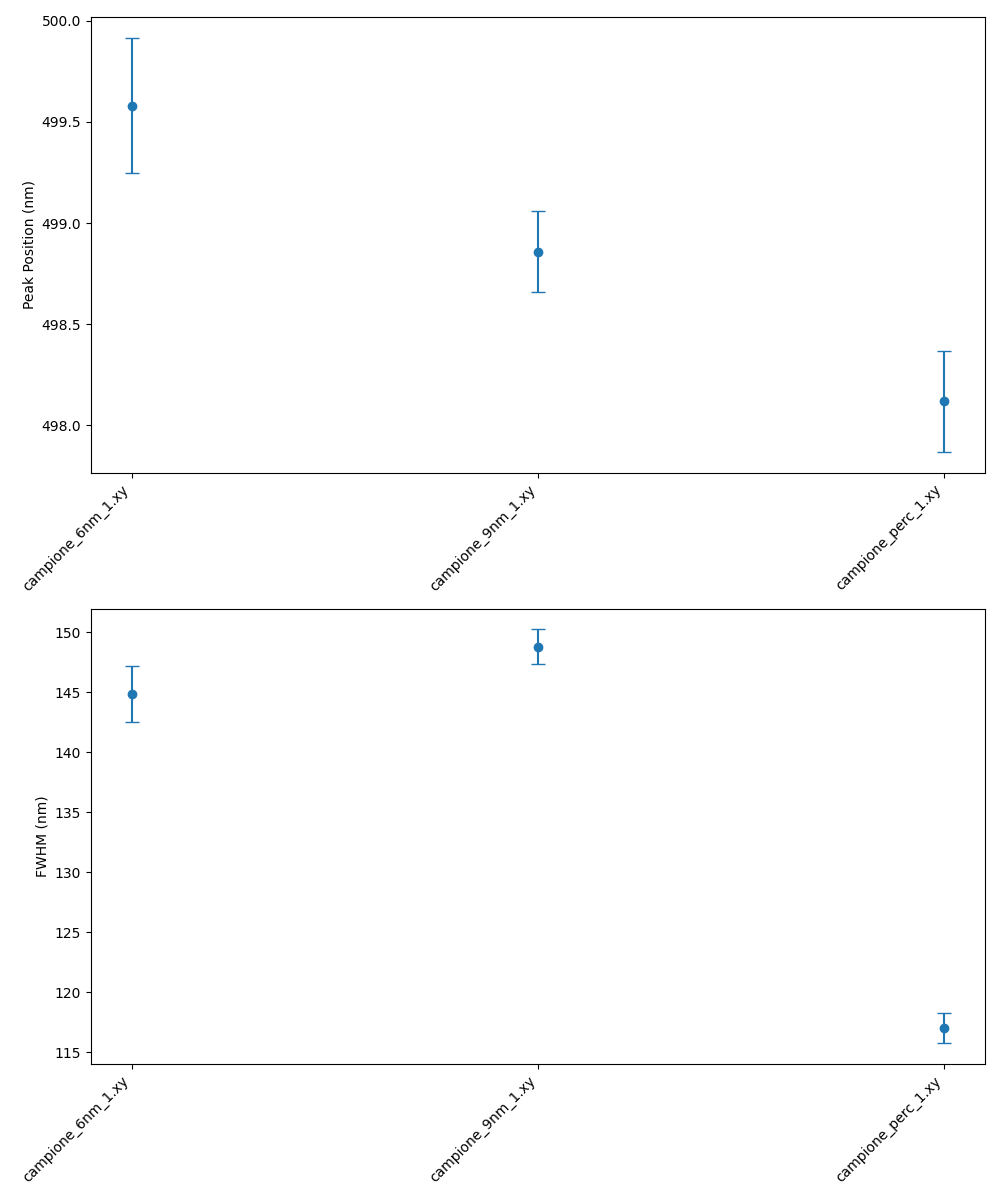

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

param_errors = {s: np.sqrt(np.diag(params[s]["covariance"])) for s in ordered_spectra}

# posizione picchi
ax = axes[0]
peak_positions = [params[s]["peak_position"] for s in ordered_spectra]
#ax.scatter(range(len(ordered_spectra)), peak_positions)
ax.errorbar(range(len(ordered_spectra)), peak_positions, yerr=[param_errors[s][0] for s in ordered_spectra], fmt='o', capsize=5)
ax.set_xticks(range(len(ordered_spectra)))
ax.set_xticklabels(ordered_spectra, rotation=45, ha="right")
ax.set_ylabel("Peak Position (nm)")

# larghezza picchi
ax = axes[1]
fwhm_values = [2 * params[s]["width"] for s in ordered_spectra]
ax.errorbar(range(len(ordered_spectra)), fwhm_values, yerr=[param_errors[s][1] for s in ordered_spectra], fmt='o', capsize=5)
ax.set_xticks(range(len(ordered_spectra)))
ax.set_xticklabels(ordered_spectra, rotation=45, ha="right")
ax.set_ylabel("FWHM (nm)")

plt.tight_layout()
plt.show()